## LET TALK ABOUT GALTON'S WORK

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Galton father-son height data
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/HistData/Galton.csv"
df = pd.read_csv(url)
# The dataset has 'parent' and 'child' columns
df = df[['parent', 'child']].copy()
df.columns = ['father', 'son']
print(df.head())
print(f"Shape: {df.shape}")

   father   son
0    70.5  61.7
1    68.5  61.7
2    65.5  61.7
3    64.5  61.7
4    64.0  61.7
Shape: (928, 2)


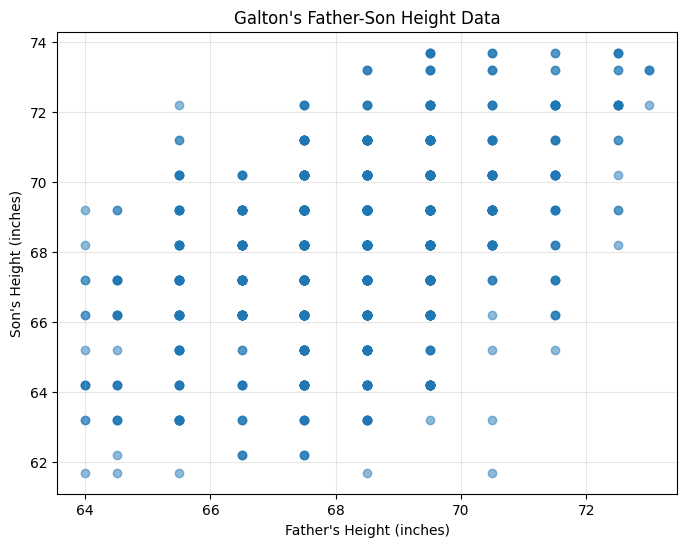

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(df['father'], df['son'], alpha=0.5)
plt.xlabel("Father's Height (inches)")
plt.ylabel("Son's Height (inches)")
plt.title("Galton's Father-Son Height Data")
plt.grid(True, alpha=0.3)

plt.show()

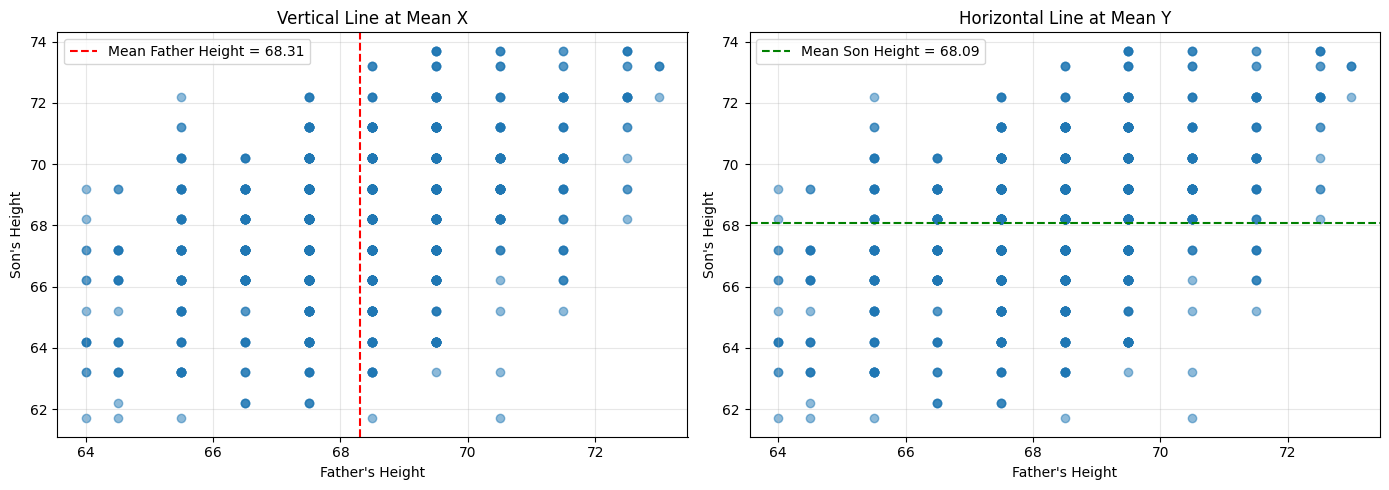

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: vertical line at mean father height
ax1.scatter(df['father'], df['son'], alpha=0.5)
ax1.axvline(df['father'].mean(), color='red', linestyle='--', 
            label=f"Mean Father Height = {df['father'].mean():.2f}")
ax1.set_xlabel("Father's Height")
ax1.set_ylabel("Son's Height")
ax1.set_title("Vertical Line at Mean X")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: horizontal line at mean son height
ax2.scatter(df['father'], df['son'], alpha=0.5)
ax2.axhline(df['son'].mean(), color='green', linestyle='--',
            label=f"Mean Son Height = {df['son'].mean():.2f}")
ax2.set_xlabel("Father's Height")
ax2.set_ylabel("Son's Height")
ax2.set_title("Horizontal Line at Mean Y")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

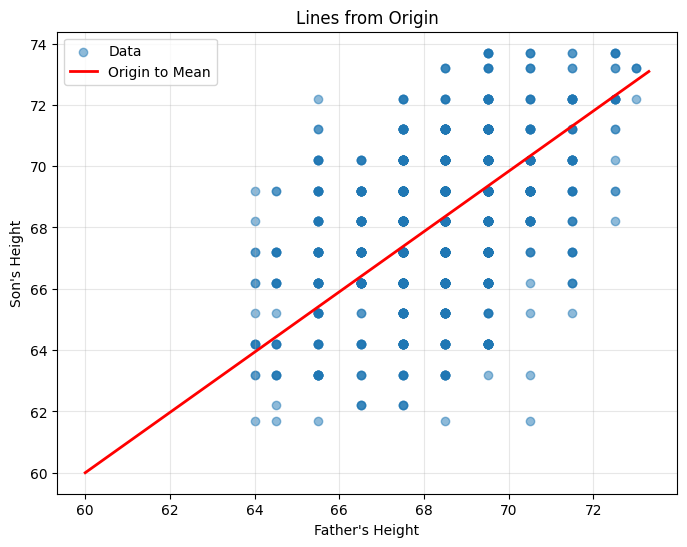

In [59]:
plt.figure(figsize=(8,6))
plt.scatter(df['father'], df['son'], alpha=0.5, label='Data')

# Option A: Line from origin to mean point
mean_x, mean_y = df['father'].mean(), df['son'].mean()
plt.plot([60, mean_x+5], [60, mean_y+5], 'r-', linewidth=2, label='Origin to Mean')

# # Option B: y=x identity line starting from origin (0,0)
# max_val = max(df['father'].max(), df['son'].max())
# plt.plot([60, max_val+5], [60, max_val+5], 'g--', label='y=x (equality)')

plt.xlabel("Father's Height")
plt.ylabel("Son's Height")
plt.title("Lines from Origin")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

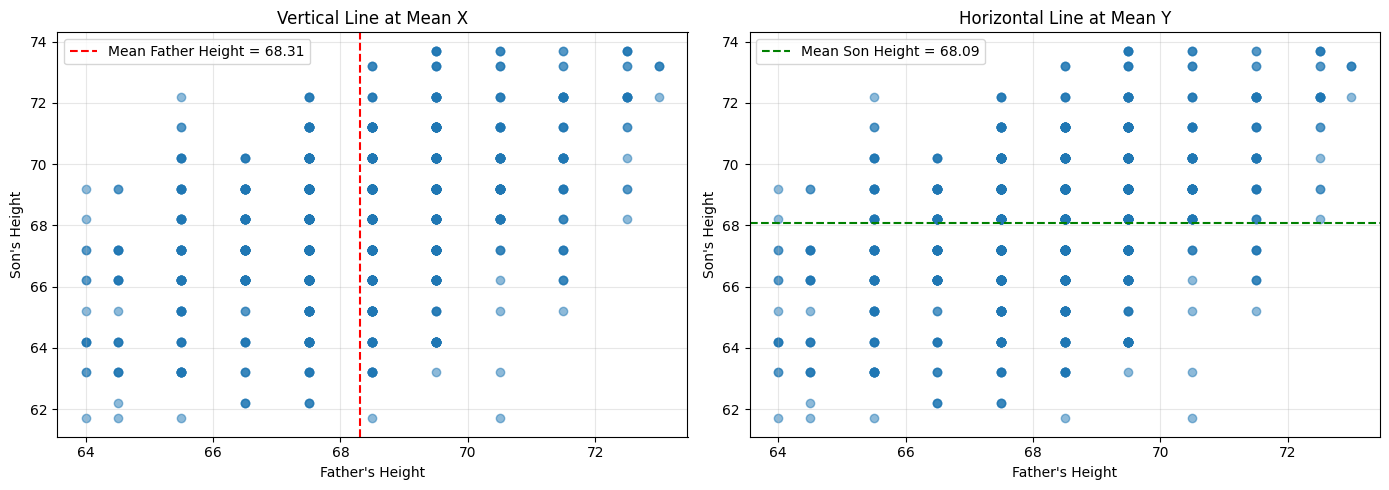

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: vertical line at mean father height
ax1.scatter(df['father'], df['son'], alpha=0.5)
ax1.axvline(df['father'].mean(), color='red', linestyle='--', 
            label=f"Mean Father Height = {df['father'].mean():.2f}")
ax1.set_xlabel("Father's Height")
ax1.set_ylabel("Son's Height")
ax1.set_title("Vertical Line at Mean X")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: horizontal line at mean son height
ax2.scatter(df['father'], df['son'], alpha=0.5)
ax2.axhline(df['son'].mean(), color='green', linestyle='--',
            label=f"Mean Son Height = {df['son'].mean():.2f}")
ax2.set_xlabel("Father's Height")
ax2.set_ylabel("Son's Height")
ax2.set_title("Horizontal Line at Mean Y")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

LINEAR REGRESSION RESULTS
Regression Equation: son = 23.942 + 0.646 * father

Coefficients:
  Slope (β₁): 0.646
  Intercept (β₀): 23.942

Model Performance:
  R² Score: 0.2105
  MSE: 5.0003
  RMSE: 2.2361


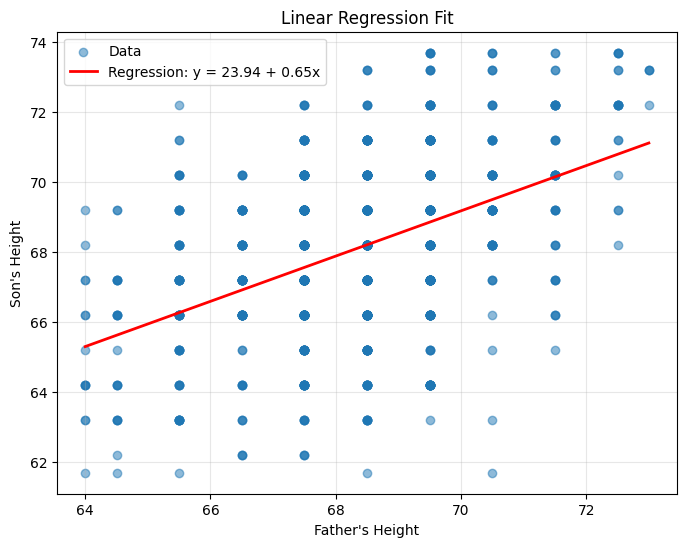

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fit the model
X = df[['father']].values
y = df['son'].values
model = LinearRegression()
model.fit(X, y)

# Get coefficients
slope = model.coef_[0]
intercept = model.intercept_

# Calculate predictions and metrics
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)
print(f"Regression Equation: son = {intercept:.3f} + {slope:.3f} * father")
print(f"\nCoefficients:")
print(f"  Slope (β₁): {slope:.3f}")
print(f"  Intercept (β₀): {intercept:.3f}")
print(f"\nModel Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  MSE: {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print("="*50)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df['father'], df['son'], alpha=0.5, label='Data')

# Plot regression line
x_line = np.linspace(df['father'].min(), df['father'].max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, 'r-', linewidth=2, 
         label=f'Regression: y = {intercept:.2f} + {slope:.2f}x')

plt.xlabel("Father's Height")
plt.ylabel("Son's Height")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Predictions:
   Father Height  Predicted Son Height
0             65             65.950418
1             68             67.889290
2             70             69.181871
3             72             70.474452
4             75             72.413324


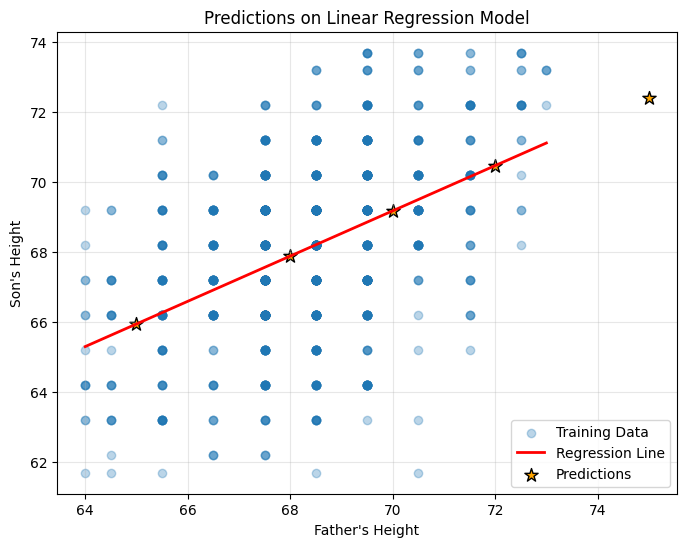

In [38]:
# Example predictions for different father heights
test_fathers = np.array([[65], [68], [70], [72], [75]])
predicted_sons = model.predict(test_fathers)

predictions_df = pd.DataFrame({
    'Father Height': test_fathers.flatten(),
    'Predicted Son Height': predicted_sons
})

print("Predictions:")
print(predictions_df)

# Visualize predictions on the plot
plt.figure(figsize=(8,6))
plt.scatter(df['father'], df['son'], alpha=0.3, label='Training Data')
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Regression Line')
plt.scatter(test_fathers, predicted_sons, color='orange', s=100, 
            marker='*', label='Predictions', edgecolors='black')
plt.xlabel("Father's Height")
plt.ylabel("Son's Height")
plt.title("Predictions on Linear Regression Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Gradient Descent Visualization - Line Updates Until Convergence

Watch how the regression line improves iteratively through gradient descent!

Starting Gradient Descent...
Initial: θ₀=60.000, θ₁=5.000
Iteration    0: θ₀=60.0000, θ₁=5.0000, MSE=37.4599
Iteration    1: θ₀=65.6950, θ₁=7.7583, MSE=6.8922
Iteration    3: θ₀=64.7138, θ₁=7.1635, MSE=5.0747
Iteration   10: θ₀=64.7850, θ₁=6.8664, MSE=5.0440
Iteration   30: θ₀=65.0325, θ₁=6.3660, MSE=5.0123
Iteration   50: θ₀=65.1620, θ₁=6.1042, MSE=5.0036
Iteration   99: θ₀=65.2750, θ₁=5.8755, MSE=5.0004
Final: θ₀=65.2760, θ₁=5.8736, MSE=5.0004
Original scale: θ₀=23.5082, θ₁=0.6526
Compare sklearn: θ₀=23.9415, θ₁=0.6463, MSE=5.0003


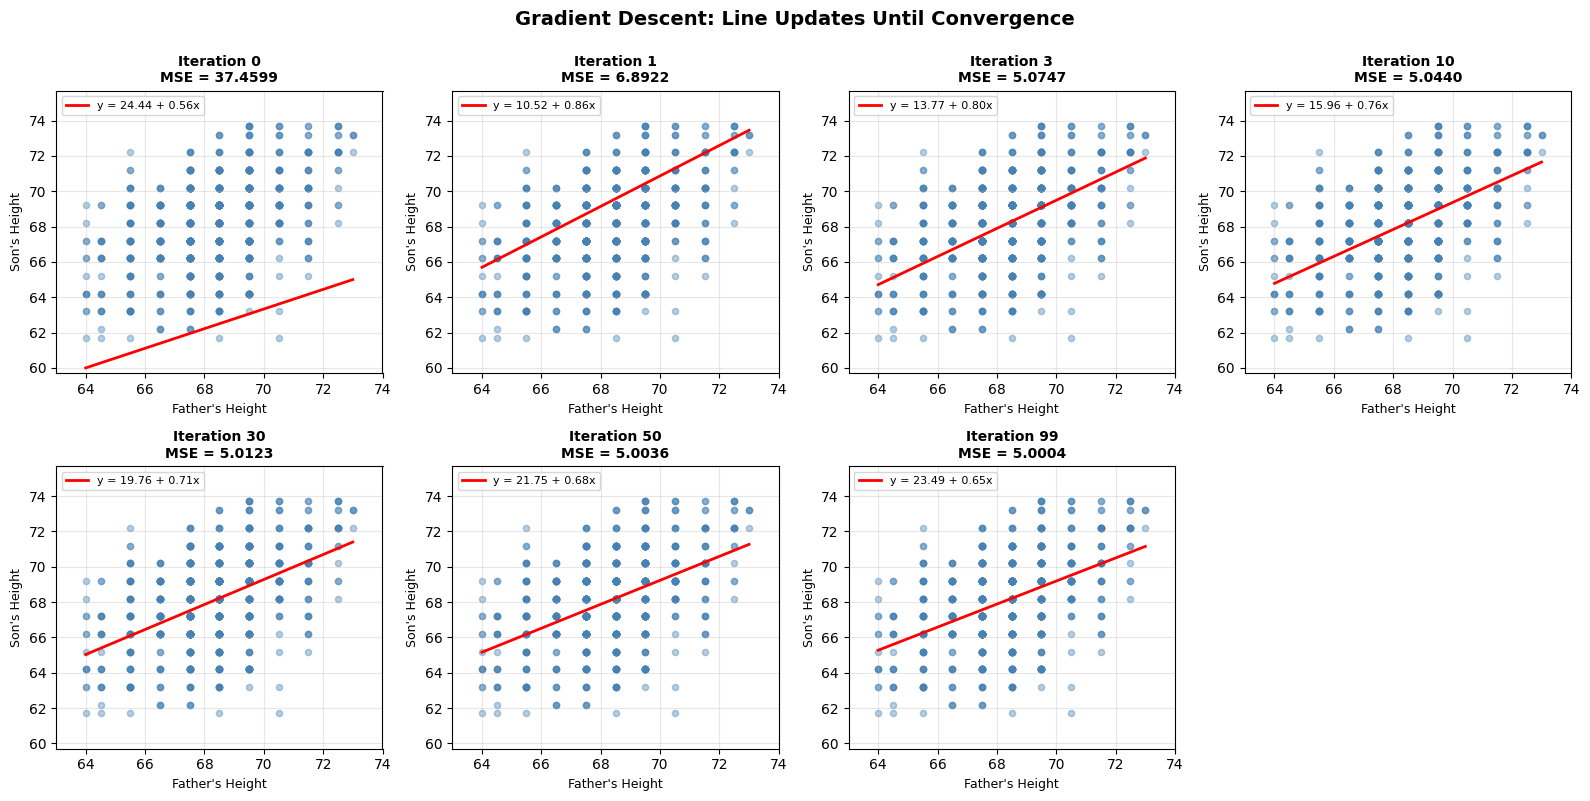

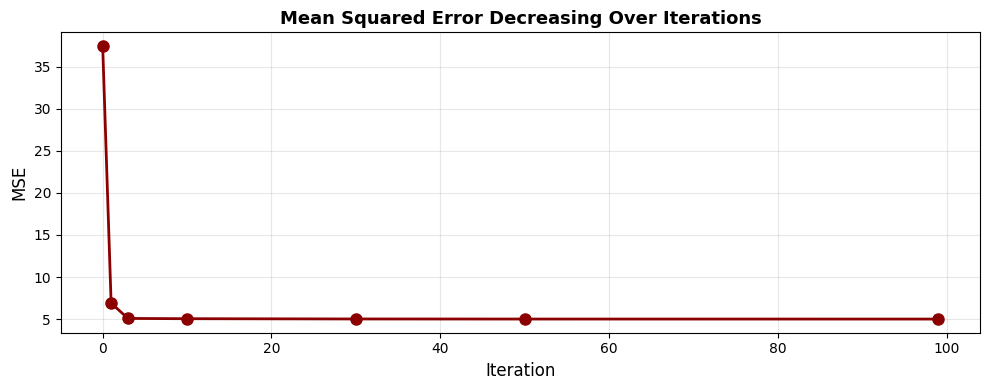

In [62]:
# Gradient Descent from Scratch - Visualizing Convergence
# Normalize features for better convergence
X_train = df['father'].values
y_train = df['son'].values
m = len(X_train)

# Normalize X to [0, 1] range for stable gradient descent
X_min, X_max = X_train.min(), X_train.max()
X_normalized = (X_train - X_min) / (X_max - X_min)

# Initialize parameters
np.random.seed(42)
theta_0 = 60.0  # Start near mean of y
theta_1 = 5.0   # Start with reasonable slope

# Hyperparameters
learning_rate = 0.5  # Larger learning rate works well with normalized features
n_iterations = 100
tolerance = 1e-6

# Store history for visualization
history = []
iterations_to_plot = [0, 1, 3, 10, 30, 50, 99]  # Key iterations to visualize

print("Starting Gradient Descent...")
print(f"Initial: θ₀={theta_0:.3f}, θ₁={theta_1:.3f}")
print("="*60)

for iteration in range(n_iterations):
    # Predictions (using normalized X)
    y_pred_gd = theta_0 + theta_1 * X_normalized
    
    # Calculate error (MSE)
    error = y_pred_gd - y_train
    mse_current = np.mean(error ** 2)
    
    # Store history for specific iterations
    if iteration in iterations_to_plot:
        history.append({
            'iteration': iteration,
            'theta_0': theta_0,
            'theta_1': theta_1,
            'mse': mse_current
        })
        print(f"Iteration {iteration:4d}: θ₀={theta_0:.4f}, θ₁={theta_1:.4f}, MSE={mse_current:.4f}")
    
    # Calculate gradients
    gradient_theta_0 = (2/m) * np.sum(error)
    gradient_theta_1 = (2/m) * np.sum(error * X_normalized)
    
    # Update parameters
    theta_0_new = theta_0 - learning_rate * gradient_theta_0
    theta_1_new = theta_1 - learning_rate * gradient_theta_1
    
    # Check convergence
    if abs(theta_0_new - theta_0) < tolerance and abs(theta_1_new - theta_1) < tolerance:
        print(f"\nConverged at iteration {iteration}!")
        if iteration not in iterations_to_plot:
            history.append({
                'iteration': iteration,
                'theta_0': theta_0_new,
                'theta_1': theta_1_new,
                'mse': mse_current
            })
        break
    
    theta_0 = theta_0_new
    theta_1 = theta_1_new

# Add final iteration if not converged
if iteration == n_iterations - 1 and iteration not in iterations_to_plot:
    history.append({
        'iteration': iteration,
        'theta_0': theta_0,
        'theta_1': theta_1,
        'mse': mse_current
    })

print("="*60)
print(f"Final: θ₀={theta_0:.4f}, θ₁={theta_1:.4f}, MSE={mse_current:.4f}")

# Transform back to original scale
theta_1_original = theta_1 / (X_max - X_min)
theta_0_original = theta_0 - theta_1_original * X_min
print(f"Original scale: θ₀={theta_0_original:.4f}, θ₁={theta_1_original:.4f}")
print(f"Compare sklearn: θ₀={intercept:.4f}, θ₁={slope:.4f}, MSE={mse:.4f}")

# Visualize the convergence process
n_plots = len(history)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for idx, record in enumerate(history):
    ax = axes[idx]
    
    # Plot data (original scale)
    ax.scatter(X_train, y_train, alpha=0.4, s=20, color='steelblue')
    
    # Plot current line (transform normalized parameters back to original scale)
    x_range = np.linspace(X_train.min(), X_train.max(), 100)
    x_range_normalized = (x_range - X_min) / (X_max - X_min)
    y_pred_line = record['theta_0'] + record['theta_1'] * x_range_normalized
    
    # Original scale parameters for display
    slope_orig = record['theta_1'] / (X_max - X_min)
    intercept_orig = record['theta_0'] - slope_orig * X_min
    
    ax.plot(x_range, y_pred_line, 'r-', linewidth=2,
            label=f"y = {intercept_orig:.2f} + {slope_orig:.2f}x")
    
    # Styling
    ax.set_xlabel("Father's Height", fontsize=9)
    ax.set_ylabel("Son's Height", fontsize=9)
    ax.set_title(f"Iteration {record['iteration']}\nMSE = {record['mse']:.4f}", 
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([y_train.min()-2, y_train.max()+2])
    ax.set_xlim([X_train.min()-1, X_train.max()+1])

# Hide extra subplots if any
for idx in range(n_plots, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Gradient Descent: Line Updates Until Convergence', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Plot MSE vs Iteration
plt.figure(figsize=(10, 4))
iterations_list = [h['iteration'] for h in history]
mse_list = [h['mse'] for h in history]
plt.plot(iterations_list, mse_list, 'o-', linewidth=2, markersize=8, color='darkred')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Mean Squared Error Decreasing Over Iterations', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
θ₀=65.2750, θ₁=5.8755
x = 75 
y  = θ₀ + 0₁X

In [69]:
y = 23.5082 + 0.6526 * 77

In [70]:
y

73.7584

## 1) Load Dataset
We’ll use a synthetic-but-realistic dataset: `nigerian_housing_prices.csv`.

In [40]:
df = pd.read_csv("nigerian_housing_prices.csv")
df.head()

,listing_id,state,property_type,bedrooms,bathrooms,area_sqm,age_years,distance_cbd_km,has_generator,price_ngn
0,H0001,Lagos,Apartment,2,2,78,8,9.2,1,62000000
1,H0002,Lagos,Apartment,1,1,45,12,12.5,0,32000000
2,H0003,Lagos,Duplex,4,4,210,5,18.0,1,180000000
3,H0004,Lagos,Bungalow,3,2,140,15,25.0,1,95000000
4,H0005,Lagos,Apartment,3,3,120,3,7.5,1,98000000


In [41]:
print(df.shape)
df.info()

(100, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   listing_id       100 non-null    object 
 1   state            100 non-null    object 
 2   property_type    100 non-null    object 
 3   bedrooms         100 non-null    int64  
 4   bathrooms        100 non-null    int64  
 5   area_sqm         100 non-null    int64  
 6   age_years        100 non-null    int64  
 7   distance_cbd_km  100 non-null    float64
 8   has_generator    100 non-null    int64  
 9   price_ngn        100 non-null    int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 7.9+ KB


In [42]:
# Quick sanity checks
print(df.isna().sum())
print("\nTarget summary:")
print(df["price_ngn"].describe())

listing_id         0
state              0
property_type      0
bedrooms           0
bathrooms          0
area_sqm           0
age_years          0
distance_cbd_km    0
has_generator      0
price_ngn          0
dtype: int64

Target summary:
count    1.000000e+02
mean     7.175000e+07
std      5.451501e+07
min      1.600000e+07
25%      3.200000e+07
50%      5.650000e+07
75%      9.200000e+07
max      2.800000e+08
Name: price_ngn, dtype: float64


## 2) Define Features/Target
Target: `price_ngn`.

We’ll treat:
- numeric: bedrooms, bathrooms, area_sqm, age_years, distance_cbd_km
- binary numeric: has_generator
- categorical: state, property_type

In [43]:
TARGET = "price_ngn"

numeric_features = [
    "bedrooms",
    "bathrooms",
    "area_sqm",
    "age_years",
    "distance_cbd_km",
    "has_generator",
]

categorical_features = ["state", "property_type"]

X = df[numeric_features + categorical_features]
y = df[TARGET]

X.head()

,bedrooms,bathrooms,area_sqm,age_years,distance_cbd_km,has_generator,state,property_type
0,2,2,78,8,9.2,1,Lagos,Apartment
1,1,1,45,12,12.5,0,Lagos,Apartment
2,4,4,210,5,18.0,1,Lagos,Duplex
3,3,2,140,15,25.0,1,Lagos,Bungalow
4,3,3,120,3,7.5,1,Lagos,Apartment


## 3) Train/Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (80, 8) Test: (20, 8)


## 4) Build a Baseline Pipeline
Why pipeline?
- prevents leakage
- keeps preprocessing consistent
- works cleanly with cross-validation

In [45]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression()),
    ]
)

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 5) Train + Evaluate
We’ll report:
- MAE (lower is better)
- RMSE (lower is better)
- $R^2$ (higher is better)

In [46]:
baseline_model.fit(X_train, y_train)

pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"Baseline Linear Regression")
print(f"MAE : ₦{mae:,.0f}")
print(f"RMSE: ₦{rmse:,.0f}")
print(f"R^2 : {r2:.3f}")

Baseline Linear Regression
MAE : ₦16,923,000
RMSE: ₦20,514,951
R^2 : 0.901


## 6) Polynomial Regression (Numeric Features)
We will apply polynomial features only to numeric columns, then still one-hot encode categorical columns.

We’ll compare degree 1 vs degree 2.

In [49]:
poly_numeric_transformer_deg2 = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
    ]
)

preprocess_poly2 = ColumnTransformer(
    transformers=[
        ("num", poly_numeric_transformer_deg2, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

poly2_model = Pipeline(
    steps=[
        ("preprocess", preprocess_poly2),
        ("model", LinearRegression()),
    ]
)

poly2_model.fit(X_train, y_train)
pred2 = poly2_model.predict(X_test)

mae2 = mean_absolute_error(y_test, pred2)
rmse2 = root_mean_squared_error(y_test, pred2)
r2_2 = r2_score(y_test, pred2)

print("Polynomial (degree=2) + LinearRegression")
print(f"MAE : ₦{mae2:,.0f}")
print(f"RMSE: ₦{rmse2:,.0f}")
print(f"R^2 : {r2_2:.3f}")

Polynomial (degree=2) + LinearRegression
MAE : ₦10,686,319
RMSE: ₦13,153,210
R^2 : 0.959


## 7) Quick Discussion
- If degree 2 helps: the relationship is likely non-linear.
- If degree 2 hurts: might be overfitting, or not needed.

Next: We’ll control overfitting using regularization and tune hyperparameters.